In [2]:
import os, glob, re
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import re
import scipy.io as sio

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_GPUS = torch.cuda.device_count()
print("Using GPUs:", NUM_GPUS)

IMG_SIZE = 192
SEQ_LEN = 5
BATCH_SIZE = 8
EPOCHS = 6
LR = 1e-4
HIDDEN_CH = 96
DROPOUT = 0.35

TRAIN_IMG_DIR = "//kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/training_videos"
TRAIN_VOL_DIR = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/training_vol"
TEST_IMG_DIR  = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_videos"
TEST_VOL_DIR  = "/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_vol"

TEMPLATE_CSV = "/kaggle/input/sample/submission-8.csv"

OUT_CSV = "submission_mat_best.csv"


def canonical_id(x):
    nums = re.findall(r"\d+", str(x))
    if len(nums) < 2:
        return None
    return f"{int(nums[0]):02d}_{int(nums[1]):04d}"

def preprocess_frame(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.bilateralFilter(img, 5, 75, 75)
    return img.astype("float32") / 255.0

def unflip_if_needed(img):
    if img[:IMG_SIZE//2].mean() > img[IMG_SIZE//2:].mean():
        return np.flipud(img)
    return img

def load_vol(path):
    vol = sio.loadmat(path)["vol"].astype("float32")
    if vol.shape[1] != IMG_SIZE:
        vol = np.stack([cv2.resize(vol[t], (IMG_SIZE, IMG_SIZE)) for t in range(len(vol))])
    return vol

print("Computing global vol statistics...")
all_vals = []



for fname in sorted(os.listdir(TRAIN_VOL_DIR)):
    if not fname.endswith(".mat"):
        continue

    # fname = "vol01.mat"
    vid = int(re.findall(r"\d+", fname)[0])   # safely extract 01
    vpath = os.path.join(TRAIN_VOL_DIR, fname)

    vol = load_vol(vpath)
    all_vals.append(vol.reshape(-1))

all_vals = np.concatenate(all_vals)
VOL_MIN = np.percentile(all_vals, 2)
VOL_MAX = np.percentile(all_vals, 98)
print("VOL MIN/MAX:", VOL_MIN, VOL_MAX)

def normalize_vol(vol):
    vol = np.clip(vol, VOL_MIN, VOL_MAX)
    return (vol - VOL_MIN) / (VOL_MAX - VOL_MIN + 1e-8)

class AvenueMatDataset(Dataset):
    def __init__(self, img_root, vol_root):
        self.samples = []
        self.data = []

        for vid in sorted(os.listdir(img_root)):
            img_paths = sorted(glob.glob(os.path.join(img_root, vid, "*.jpg")))
            frames = [unflip_if_needed(preprocess_frame(p)) for p in img_paths]
            frames = np.stack(frames)

            vol = normalize_vol(load_vol(
                os.path.join(vol_root, f"vol{int(vid):02d}.mat")
            ))

            T = min(len(frames), len(vol))
            frames, vol = frames[:T], vol[:T]
            self.data.append((frames, vol))

            for i in range(SEQ_LEN, T):
                self.samples.append((len(self.data)-1, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        di, i = self.samples[idx]
        frames, vol = self.data[di]
        x = np.stack([frames[i-SEQ_LEN:i], vol[i-SEQ_LEN:i]], axis=1)
        y = frames[i]
        return torch.tensor(x), torch.tensor(y).unsqueeze(0)


class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch + hidden_ch, 4 * hidden_ch, 3, padding=1)
        self.bn = nn.BatchNorm2d(4 * hidden_ch)

    def forward(self, x, h, c):
        g = self.bn(self.conv(torch.cat([x, h], dim=1)))
        i, f, o, g = torch.chunk(g, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

class CNNConvLSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(DROPOUT),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.convlstm = ConvLSTMCell(64, HIDDEN_CH)
        self.decoder = nn.Sequential(
            nn.Conv2d(HIDDEN_CH, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(DROPOUT),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, HIDDEN_CH, H, W, device=x.device)
        c = torch.zeros_like(h)
        for t in range(T):
            feat = self.encoder(x[:, t])
            h, c = self.convlstm(feat, h, c)
        return self.decoder(h)

dataset = AvenueMatDataset(TRAIN_IMG_DIR, TRAIN_VOL_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8,pin_memory = True)

model = CNNConvLSTMPredictor().to(DEVICE)
if NUM_GPUS > 1:
    model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for x, y in tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f"Epoch {epoch} | Loss: {total/len(loader):.6f}")

    if epoch%1 == 0:
        state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
        torch.save(state, f"model_{epoch}.pth")
        print("Saved",f"model_{epoch}.pth")


Using GPUs: 2
Computing global vol statistics...
VOL MIN/MAX: 18.03038215637207 203.234375


Epoch 1/6: 100%|██████████| 230/230 [02:11<00:00,  1.74it/s]


Epoch 1 | Loss: 0.005401
Saved model_1.pth


Epoch 2/6: 100%|██████████| 230/230 [02:24<00:00,  1.59it/s]


Epoch 2 | Loss: 0.002686
Saved model_2.pth


...

Epoch 4 | Loss: 0.002095
Saved model_4.pth


Epoch 5/6: 100%|██████████| 230/230 [02:34<00:00,  1.49it/s]


Epoch 5 | Loss: 0.001971
Saved model_5.pth


Epoch 6/6: 100%|██████████| 230/230 [02:34<00:00,  1.49it/s]

Epoch 6 | Loss: 0.001937
Saved model_6.pth


In [5]:
def generate_submission():
    import os, glob
    import numpy as np
    import pandas as pd
    import torch
    from tqdm import tqdm

    sample = pd.read_csv(TEMPLATE_CSV)
    sample["Predicted"] = 0.0

    model = CNNConvLSTMPredictor().to(DEVICE)
    state = torch.load("/kaggle/working/model_5.pth", map_location=DEVICE)

    # handle DataParallel checkpoints
    if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", ""): v for k, v in state.items()}

    model.load_state_dict(state)
    model.eval()

    score_map = {}
    all_scores = []

    BATCH_INF = 32

    with torch.no_grad():
        for vid in tqdm(sorted(os.listdir(TEST_IMG_DIR)), desc="Vids"):
            paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, vid, "*.jpg")))
            frames = np.stack([unflip_if_needed(preprocess_frame(p)) for p in paths])
            frame_nums = [extract_frame_number(p) for p in paths]

            batch_x, batch_gt, batch_fid = [], [], []

            for i in range(SEQ_LEN, len(frames)):
                seq = frames[i-SEQ_LEN:i]
                diffs = np.concatenate(
                    [np.zeros_like(seq[:1]), seq[1:] - seq[:-1]], axis=0
                )

                x_np = np.stack([seq, diffs], axis=1)
                batch_x.append(x_np)
                batch_gt.append(frames[i])

                # ✅ EXACT Kaggle ID format
                fid = f"{int(vid)}_{frame_nums[i]}"
                batch_fid.append(fid)

                if len(batch_x) == BATCH_INF or i == len(frames) - 1:
                    batch = torch.from_numpy(np.array(batch_x)).to(DEVICE)
                    preds = model(batch)[:, 0]

                    for p, gt, fid in zip(preds, batch_gt, batch_fid):
                        gt = torch.tensor(gt, device=DEVICE)
                        err = torch.mean((p - gt) ** 2).item()
                        score_map[fid] = err
                        all_scores.append(err)

                    batch_x.clear()
                    batch_gt.clear()
                    batch_fid.clear()

    # ===== GLOBAL percentile normalization =====
    all_scores = np.array(all_scores)
    lo, hi = np.percentile(all_scores, 2), np.percentile(all_scores, 98)
    all_scores = np.clip(all_scores, lo, hi)
    mn, mx = all_scores.min(), all_scores.max()

    for k in score_map:
        score_map[k] = (score_map[k] - mn) / (mx - mn + 1e-8)

    # fill submission template
    for i in range(len(sample)):
        fid = sample.at[i, "Id"]
        if fid in score_map:
            sample.at[i, "Predicted"] = score_map[fid]

    # safety clamp
    sample["Predicted"] = sample["Predicted"].clip(0.0, 1.0)

    sample.to_csv("submission.csv", index=False)
    print("submission.csv generated correctly")

In [7]:
def extract_frame_number(path):

    name = os.path.basename(path)          # frame_0939.jpg
    num = name.split("_")[-1].split(".")[0]
    return int(num)

In [8]:
if __name__ == "__main__":
    generate_submission()

Vids: 100%|██████████| 21/21 [09:00<00:00, 25.75s/it]


✅ submission.csv generated correctly


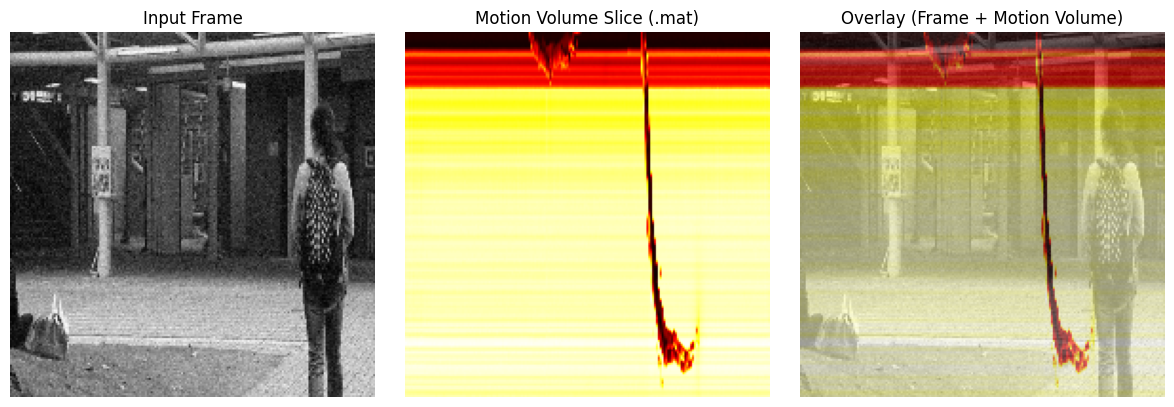

In [7]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import cv2

def visualize_vol_slice(
    img_path,
    vol_path,
    frame_idx=50,
    img_size=192
):
    # load image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32") / 255.0

    # load vol
    vol = sio.loadmat(vol_path)["vol"].astype("float32")
    vol_slice = vol[frame_idx]

    if vol_slice.shape != (img_size, img_size):
        vol_slice = cv2.resize(vol_slice, (img_size, img_size))

    # normalize vol slice for display
    vol_norm = (vol_slice - vol_slice.min()) / (vol_slice.max() - vol_slice.min() + 1e-8)

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Input Frame")
    axes[0].axis("off")

    axes[1].imshow(vol_norm, cmap="hot")
    axes[1].set_title("Motion Volume Slice (.mat)")
    axes[1].axis("off")

    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(vol_norm, cmap="hot", alpha=0.6)
    axes[2].set_title("Overlay (Frame + Motion Volume)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_vol_slice(
    img_path="/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_videos/01/frame_01041.jpg",
    vol_path="/kaggle/input/pixel-play-26/Avenue_Corrupted-20251221T112159Z-3-001/Avenue_Corrupted/Dataset/testing_vol/vol01.mat",
    frame_idx=99
)